In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df_no159 = pd.read_excel('All-NO159-2.xlsx')
df_j4= pd.read_excel('All-J4ST2.xlsx')
df_159 = pd.read_excel('All-NO 159-1 .xlsx')


In [3]:
df_j4= df_j4.iloc[:,[0,1,2]] #J4ST2
df_no159= df_no159.iloc[:,[0,1,2]] #NO159-2
df_159= df_159.iloc[:,[0,1,2]] # NO159-1

In [4]:
# Create a list of your dataframes and their names for easy iteration
wells = [
    (df_no159, "NO159-2"),
    (df_j4, "J4ST2"),
    (df_159, "NO159-1")
]

print(f"{'Well Name':<12} | {'Top (ft)':<10} | {'Bottom (ft)':<10} | {'Interval (ft)':<15} | {'Samples':<8}")
print("-" * 65)

for df, name in wells:
    # 1. Identify the Depth column (it's the first column)
    depth_col = df.columns[0]
    
    # 2. Extract Top and Bottom
    top_depth = df[depth_col].min()
    bottom_depth = df[depth_col].max()
    
    # 3. Calculate the physical Interval (Vertical thickness)
    interval = bottom_depth - top_depth
    
    # 4. Get the count of data points (Samples)
    num_samples = len(df)
    
    print(f"{name:<12} | {top_depth:<10.2f} | {bottom_depth:<10.2f} | {interval:<15.2f} | {num_samples:<8}")

Well Name    | Top (ft)   | Bottom (ft) | Interval (ft)   | Samples 
-----------------------------------------------------------------
NO159-2      | 5000.00    | 5150.00    | 150.00          | 150     
J4ST2        | 5000.00    | 5150.00    | 150.00          | 150     
NO159-1      | 5000.00    | 5150.00    | 150.00          | 150     


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# --- 2. DTW ALGORITHM WITH SAKOE-CHIBA CONSTRAINT ---
def dtw_sakoe_chiba(s1, s2, window_percent=0.15):
    """
    Computes the DTW distance between two standardized log sequences.
    window_percent: The width of the Sakoe-Chiba constraint band.
    """
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Calculate window size and ensure it covers the difference in log lengths
    window = int(window_percent * max(n, m))
    window = max(window, abs(n - m))

    for i in range(1, n + 1):
        # Calculate within the Sakoe-Chiba band
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            # Cost is the absolute difference between standardised values
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],    # insertion
                                          dtw_matrix[i, j-1],    # deletion
                                          dtw_matrix[i-1, j-1])  # match
    return dtw_matrix[n, m]

# --- 3. STANDARDIZATION (Z-Score) ---
scaler = StandardScaler()


In [6]:
# Standardize the NPHI for your 3 existing dataframes
nphi_no159 = scaler.fit_transform(df_no159[['Neutron Porosity']].values).flatten()
nphi_159 = scaler.fit_transform(df_159[['Neutron Porosity']].values).flatten()
nphi_j4 = scaler.fit_transform(df_j4[['Neutron Porosity']].values).flatten()
# converting gr values such that MEAN =0 STD DEV =1

# Calculate NPHI Distances for all combinations
dist_nphi_no_159 = dtw_sakoe_chiba(nphi_no159, nphi_159, int(0.15 * max(len(nphi_no159), len(nphi_159))))
dist_nphi_159_j4 = dtw_sakoe_chiba(nphi_159, nphi_j4, int(0.15 * max(len(nphi_159), len(nphi_j4))))
dist_nphi_j4_no = dtw_sakoe_chiba(nphi_j4, nphi_no159, int(0.15 * max(len(nphi_j4), len(nphi_no159))))

print(f"NPHI Distance NO159-159: {dist_nphi_no_159:.2f}")
print(f"NPHI Distance 159-J4: {dist_nphi_159_j4:.2f}")
print(f"NPHI Distance J4-NO159: {dist_nphi_j4_no:.2f}")

NPHI Distance NO159-159: 80.47
NPHI Distance 159-J4: 83.91
NPHI Distance J4-NO159: 76.97


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standardize the GR for your 3 existing dataframes
gr_no159 = scaler.fit_transform(df_no159[['GR (API)']].values).flatten()
gr_159 = scaler.fit_transform(df_159[['GR (API)']].values).flatten()
gr_j4 = scaler.fit_transform(df_j4[['GR (API)']].values).flatten()

# Calculate GR Distances for all combinations
# NO159-2 to J6A
dist_gr_no_159 = dtw_sakoe_chiba(gr_no159, gr_159, int(0.15 * max(len(gr_no159), len(gr_159))))

# J6A to J4
dist_gr_159_j4 = dtw_sakoe_chiba(gr_159, gr_j4, int(0.15 * max(len(gr_159), len(gr_j4))))

# J4 to NO159-2
dist_gr_j4_no = dtw_sakoe_chiba(gr_j4, gr_no159, int(0.15 * max(len(gr_j4), len(gr_no159))))

print(f"GR Distance NO159-J6A: {dist_gr_no_159:.2f}")
print(f"GR Distance 159-J4: {dist_gr_159_j4:.2f}")
print(f"GR Distance J4-NO159: {dist_gr_j4_no:.2f}")

GR Distance NO159-J6A: 86.36
GR Distance 159-J4: 83.92
GR Distance J4-NO159: 83.42


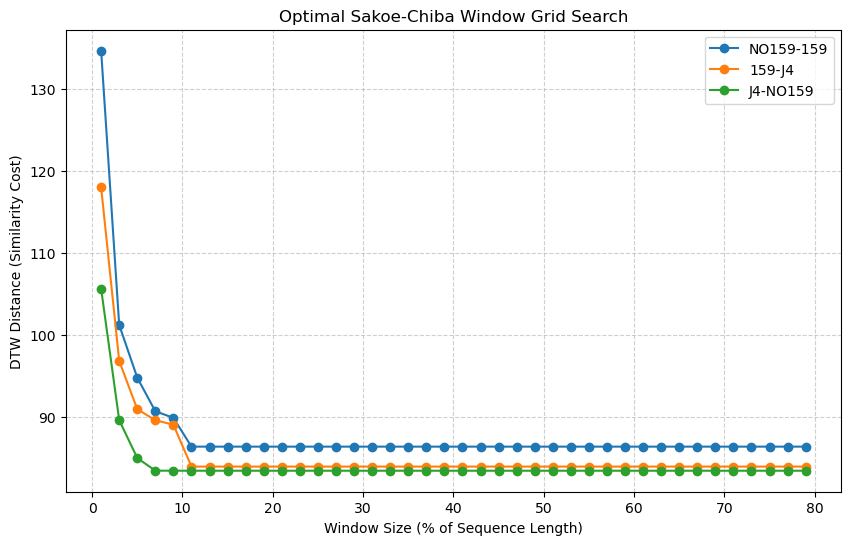

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Define DTW with Sakoe-Chiba
def dtw_sakoe_chiba(s1, s2, window):
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    # Window must be at least the difference in lengths
    window = max(window, abs(n - m))
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], dtw_matrix[i, j-1], dtw_matrix[i-1, j-1])
    return dtw_matrix[n, m]

# 2. Standardize GR Logs (Assuming your df_no159, df_j6a, df_j4 are ready)
scaler = StandardScaler()
gr_no159 = scaler.fit_transform(df_no159[['GR (API)']].values).flatten()
gr_159 = scaler.fit_transform(df_159[['GR (API)']].values).flatten()
gr_j4 = scaler.fit_transform(df_j4[['GR (API)']].values).flatten()

# 3. Perform Grid Search (1% to 60%)
window_percents = np.arange(1, 80, 2)
combos = [(gr_no159, gr_159, "NO159-159"), (gr_159, gr_j4, "159-J4"), (gr_j4, gr_no159, "J4-NO159")]
all_results = {}

for s1, s2, label in combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    all_results[label] = distances

# 4. Plot the Elbow Curves
plt.figure(figsize=(10, 6))
for label, distances in all_results.items():
    plt.plot(window_percents, distances, marker='o', label=label)

plt.title('Optimal Sakoe-Chiba Window Grid Search')
plt.xlabel('Window Size (% of Sequence Length)')
plt.ylabel('DTW Distance (Similarity Cost)')
plt.savefig('GR_Sakoe.png', dpi=300, bbox_inches='tight')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [9]:
# Create a small function to find the first percentage that hits the 'floor'
def get_best_window(percent_list, distance_list):
    # Find the minimum distance achieved
    min_dist = min(distance_list)
    # Find the index of the first time that minimum was reached
    best_index=distance_list.index(min_dist)    
# Return the corresponding percentage
    return percent_list[best_index]

# Use the variables from your previous grid search loop
best_no_159 = get_best_window(window_percents.tolist(), all_results["NO159-159"])
best_159_j4 = get_best_window(window_percents.tolist(), all_results["159-J4"])
best_j4_no = get_best_window(window_percents.tolist(), all_results["J4-NO159"])

print(f"Optimal Window for NO159-159: {best_no_159}%")
print(f"Optimal Window for 159-J4: {best_159_j4}%")
print(f"Optimal Window for J4-NO159: {best_j4_no}%")

Optimal Window for NO159-159: 11%
Optimal Window for 159-J4: 11%
Optimal Window for J4-NO159: 11%


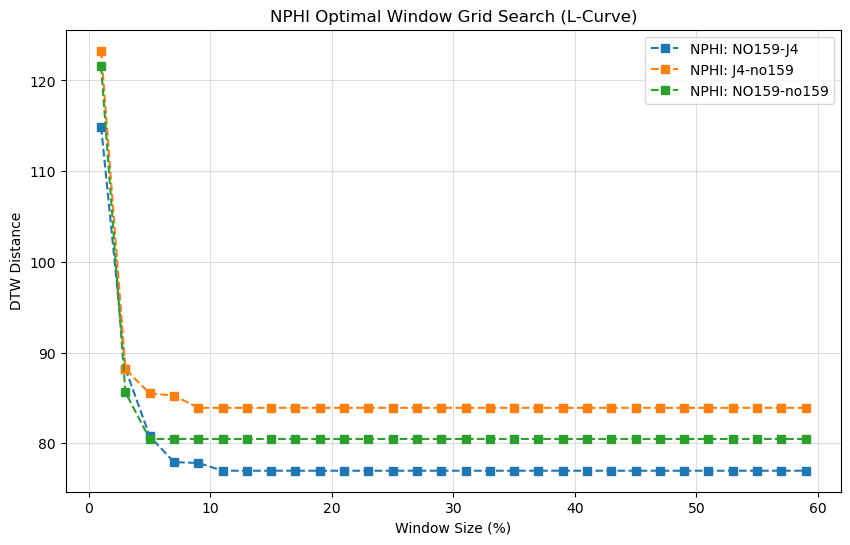

--- Optimized NPHI Windows ---
NO159-J4: 11%
j4-159:    9%
NO159-159:  5%


In [10]:
# 1. Define the range for NPHI Grid Search
window_percents = np.arange(1, 61, 2)
nphi_combos = [
    (nphi_no159, nphi_j4, "NO159-J4"),
    (nphi_159, nphi_j4, "J4-no159"),
    (nphi_159, nphi_no159, "NO159-no159")
]

nphi_grid_results = {}

# 2. Execute Grid Search for NPHI
for s1, s2, label in nphi_combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    nphi_grid_results[label] = distances

# 3. Plot NPHI L-Curves
plt.figure(figsize=(10, 6))
for label, distances in nphi_grid_results.items():
    plt.plot(window_percents, distances, marker='s', linestyle='--', label=f"NPHI: {label}")

plt.title('NPHI Optimal Window Grid Search (L-Curve)')
plt.xlabel('Window Size (%)')
plt.ylabel('DTW Distance')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

# 4. Function to identify the 'Elbow' (First point of stability)
def find_nphi_best_window(p_list, d_list):
    # Find the absolute minimum distance
    min_d = min(d_list)
    # Find the first index where the distance is within 0.5% of the minimum
    for i, d in enumerate(d_list):
        if (d - min_d) / min_d < 0.005:
            return p_list[i]
    return p_list[-1]

# 5. Output the Best Windows for NPHI
best_nphi_NO159_J4 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["NO159-J4"])
best_nphi_j4_no159 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J4-no159"])
best_nphi_NO159_no159 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["NO159-no159"])

print(f"--- Optimized NPHI Windows ---")
print(f"NO159-J4: {best_nphi_NO159_J4}%")
print(f"j4-159:    {best_nphi_j4_no159}%")
print(f"NO159-159:  {best_nphi_NO159_no159}%")

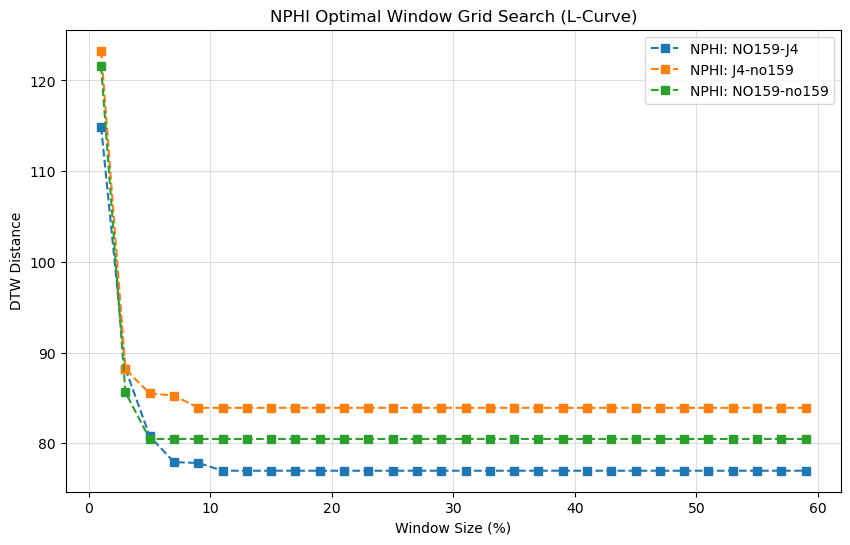

--- Optimized NPHI Windows ---
NO159-J4: 11%
j4-159:    9%
NO159-159:  5%


In [11]:
# 1. Define the range for NPHI Grid Search
window_percents = np.arange(1, 61, 2)
nphi_combos = [
    (nphi_no159, nphi_j4, "NO159-J4"),
    (nphi_159, nphi_j4, "J4-no159"),
    (nphi_159, nphi_no159, "NO159-no159")
]

nphi_grid_results = {}

# 2. Execute Grid Search for NPHI
for s1, s2, label in nphi_combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    nphi_grid_results[label] = distances

# 3. Plot NPHI L-Curves
plt.figure(figsize=(10, 6))
for label, distances in nphi_grid_results.items():
    plt.plot(window_percents, distances, marker='s', linestyle='--', label=f"NPHI: {label}")

plt.title('NPHI Optimal Window Grid Search (L-Curve)')
plt.xlabel('Window Size (%)')
plt.ylabel('DTW Distance')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

# 4. Function to identify the 'Elbow' (First point of stability)
def find_nphi_best_window(p_list, d_list):
    # Find the absolute minimum distance
    min_d = min(d_list)
    # Find the first index where the distance is within 0.5% of the minimum
    for i, d in enumerate(d_list):
        if (d - min_d) / min_d < 0.005:
            return p_list[i]
    return p_list[-1]

# 5. Output the Best Windows for NPHI
best_nphi_NO159_J4 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["NO159-J4"])
best_nphi_j4_no159 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J4-no159"])
best_nphi_NO159_no159 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["NO159-no159"])

print(f"--- Optimized NPHI Windows ---")
print(f"NO159-J4: {best_nphi_NO159_J4}%")
print(f"j4-159:    {best_nphi_j4_no159}%")
print(f"NO159-159:  {best_nphi_NO159_no159}%")

## no159(2)-J4ST2

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Publication-ready styling (Standardized for all plots)
# 1. MATCHING GLOBAL STYLE
plt.rcParams.update({
    "font.family": "serif",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 30,       # Matches Warping Path Axis Labels
    "axes.titlesize": 34,       # Matches Warping Path Title
    "legend.fontsize": 30,      # Matches Warping Path Legend
    "figure.figsize": (18, 18), # Matches Warping Path Figure Size
    "axes.linewidth": 2.0       # Matches Warping Path Spine thickness
})

def find_elbow(p_list, d_list):
    min_d = min(d_list)
    for i, d in enumerate(d_list):
        if (d - min_d) / (min_d if min_d != 0 else 1) < 0.005:
            return p_list[i], d_list[i]
    return p_list[-1], d_list[-1]

In [14]:
x_gr = np.arange(1, 80, 2)
y_gr = all_results["J4-NO159"]
best_p, best_d = find_elbow(x_gr.tolist(), y_gr)


'''
plt.plot(x_gr, y_gr, color='#1f77b4', lw=2, marker='o', ms=5, label= 'DTW Cost (GR)')
plt.axvspan(best_p, max(x_gr), color='gray', alpha=0.1, label='Stability Zone')
plt.scatter(best_p, best_d, color='red', edgecolor='black', s=100, marker='*', zorder=5)


fig, ax = plt.subplots() # Use subplots for better control

ax.plot(x_gr, y_gr, color='#1f77b4', lw=5, marker='o', ms=12, label='DTW Cost (GR)')
ax.axvspan(best_p, max(x_gr), color='gray', alpha=0.15, label='Stability Zone')
ax.scatter(best_p, best_d, color='red', edgecolor='black', s=400, marker='*', zorder=10)


#plt.annotate(f'Optimum: {best_p}%', xy=(best_p, best_d), xytext=(best_p+10, best_d+1), arrowprops=dict(arrowstyle='->'))
ax.annotate(f'Optimum Window: {best_p}%', xy=(best_p, best_d), xytext=(best_p+10, best_d + 5),
             fontsize=30, fontweight='bold', # Set font specifically
             arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", lw=2),
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))


# 3. MATCHING TICK LABELS
ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')


ax.set_title("Optimization: J4ST2 vs NO159-2 (Gamma Ray)", pad=30)
ax.set_xlabel("Sakoe-Chiba Window Size (% of Sequence Length)", labelpad=15)
ax.set_ylabel("DTW Distance (Similarity Cost)", labelpad= 15)
ax.grid(True, linestyle='--', alpha=0.6)

ax.legend(loc='upper right', frameon=True, shadow=True, framealpha=0.9)

plt.tight_layout()

plt.savefig("L_curve/NO159(2)_J4ST2_GR.jpg", dpi=300, bbox_inches='tight')
plt.show()

'''




'\nplt.plot(x_gr, y_gr, color=\'#1f77b4\', lw=2, marker=\'o\', ms=5, label= \'DTW Cost (GR)\')\nplt.axvspan(best_p, max(x_gr), color=\'gray\', alpha=0.1, label=\'Stability Zone\')\nplt.scatter(best_p, best_d, color=\'red\', edgecolor=\'black\', s=100, marker=\'*\', zorder=5)\n\n\nfig, ax = plt.subplots() # Use subplots for better control\n\nax.plot(x_gr, y_gr, color=\'#1f77b4\', lw=5, marker=\'o\', ms=12, label=\'DTW Cost (GR)\')\nax.axvspan(best_p, max(x_gr), color=\'gray\', alpha=0.15, label=\'Stability Zone\')\nax.scatter(best_p, best_d, color=\'red\', edgecolor=\'black\', s=400, marker=\'*\', zorder=10)\n\n\n#plt.annotate(f\'Optimum: {best_p}%\', xy=(best_p, best_d), xytext=(best_p+10, best_d+1), arrowprops=dict(arrowstyle=\'->\'))\nax.annotate(f\'Optimum Window: {best_p}%\', xy=(best_p, best_d), xytext=(best_p+10, best_d + 5),\n             fontsize=30, fontweight=\'bold\', # Set font specifically\n             arrowprops=dict(arrowstyle=\'->\', connectionstyle="arc3,rad=.2", lw=2

In [15]:

import matplotlib.pyplot as plt
import numpy as np

# 1. MATCHING GLOBAL STYLE (Synchronized with Warping Path & GR)
plt.rcParams.update({
    "font.family": "serif",
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 30,       # Matches Warping Path Axis Labels
    "axes.titlesize": 34,       # Matches Warping Path Title
    "legend.fontsize": 30,      # Matches Warping Path Legend
    "figure.figsize": (18, 18), # Matches Warping Path 1:1 Aspect Ratio
    "axes.linewidth": 2.0       # Matches Warping Path Spine thickness
})



x_nphi = np.arange(1, 61, 2)
y_nphi = nphi_grid_results["NO159-J4"]
best_p_nphi, best_d_nphi = find_elbow(x_nphi.tolist(), y_nphi)
'''
fig, ax = plt.subplots()
ax.plot(x_nphi, y_nphi, color='#2ca02c', lw=5, marker='s', ms=12, label='DTW Cost (NPHI)')
ax.axvspan(best_p_nphi, max(x_nphi), color='gray', alpha=0.15, label='Stability Zone')

ax.scatter(best_p_nphi, best_d_nphi, color='red', edgecolor='black', s=400, marker='*', zorder=10)

ax.annotate(f'Optimum Window: {best_p}%', xy=(best_p, best_d), xytext=(best_p+10, best_d + 5),
             fontsize=30, fontweight='bold',
             arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2",lw=2),
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))

# 4. MATCHING TICK LABELS (16pt Bold)
ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')


ax.set_title("Optimization: J4ST2 vs NO159-2 (NPHI)",pad=30)
ax.set_xlabel("Window Size (%)", labelpad=15)
ax.set_ylabel("DTW Distance", labelpad=15)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', frameon=True, shadow=True, framealpha=0.9)

plt.savefig("L_curve/NO159(2)_J4ST2_NPHI.jpg", dpi=300, bbox_inches='tight')

plt.show()
'''




'\nfig, ax = plt.subplots()\nax.plot(x_nphi, y_nphi, color=\'#2ca02c\', lw=5, marker=\'s\', ms=12, label=\'DTW Cost (NPHI)\')\nax.axvspan(best_p_nphi, max(x_nphi), color=\'gray\', alpha=0.15, label=\'Stability Zone\')\n\nax.scatter(best_p_nphi, best_d_nphi, color=\'red\', edgecolor=\'black\', s=400, marker=\'*\', zorder=10)\n\nax.annotate(f\'Optimum Window: {best_p}%\', xy=(best_p, best_d), xytext=(best_p+10, best_d + 5),\n             fontsize=30, fontweight=\'bold\',\n             arrowprops=dict(arrowstyle=\'->\', connectionstyle="arc3,rad=.2",lw=2),\n             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))\n\n# 4. MATCHING TICK LABELS (16pt Bold)\nax.tick_params(axis=\'both\', which=\'major\', labelsize=30, width=2, length=8)\nfor label in ax.get_xticklabels() + ax.get_yticklabels():\n    label.set_fontweight(\'bold\')\n\n\nax.set_title("Optimization: J4ST2 vs NO159-2 (NPHI)",pad=30)\nax.set_xlabel("Window Size (%)", labelpad=15)\nax.set_ylabel("DTW Distanc

## Warping path 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

def plot_dtw_path_publication_large_fonts(df1, df2, window_p, label1, label2):
    # 1. Standardize the Gamma Ray logs (Column Index 1)
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()
    
    n, m = len(s1), len(s2)
    # Applying the Sakoe-Chiba window constraint
    window = max(int(window_p * max(n, m)), abs(n - m))
    
    # 2. Compute Cumulative Cost Matrix
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # 3. Backtrack for Optimal Path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        prev_steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        best_step = np.argmin(prev_steps)
        if best_step == 0: i, j = i-1, j-1
        elif best_step == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 4. Visualization (Enhanced Font Sizes for Research)
'''
   fig, ax = plt.subplots(figsize=(18, 18)) 
    
    masked_matrix = np.ma.masked_where(dtw_matrix[1:, 1:] == np.inf, dtw_matrix[1:, 1:])
    max_cost = np.nanmax(masked_matrix)
    
    img = ax.imshow(masked_matrix.T, origin='upper', cmap='magma', 
                    aspect='auto', vmin=0, vmax=max_cost)
    
    # Plot Path & Boundaries
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=4, label='Optimal Path (GR)')
    
    # --- LARGE FONT CONFIGURATION ---
    ax.set_title(f"DTW Warping Path: {label1} vs {label2}\n(Window: {window_p*100}%)", 
                  fontsize=34, fontweight='bold', pad=30)
    
   # Axis Labels
    ax.set_xlabel(f"{label1} ", fontsize=30, fontweight='bold', labelpad=15)
    ax.set_ylabel(f"{label2} ", fontsize=30, fontweight='bold', labelpad=15)
    
    # Tick Labels (Numbers on axes)
    ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

    # Spine thickness
    for spine in ax.spines.values():
        spine.set_linewidth(2.0)

    # --- COLORBAR (Matching Large Fonts) ---
    cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
    cbar.set_label('Cumulative Similarity Cost', fontsize=30, fontweight='bold', labelpad=20)
    cbar.ax.tick_params(labelsize=30)
    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')
    
    # --- LEGEND ---
    ax.legend(fontsize=30, loc='upper right', frameon=True, shadow=True, framealpha=0.9)
    
    plt.tight_layout()
    
    
    # Save
    save_dir = 'L_curve'
    if not os.path.exists(save_dir): os.makedirs(save_dir)
    save_path = f"{save_dir}/{label1}_{label2}_WarpingPath_1pct.png"
    plt.savefig(save_path, dpi=400, bbox_inches='tight')
    
    plt.show()

# --- EXECUTE FOR NO159-2 VS J4ST2 ---
# Using 0.01 for the 1% Sakoe-Chiba parameter
plot_dtw_path_publication_large_fonts(df_no159, df_j4, 0.01, "NO159-2", "J4ST2")'''

'\n   fig, ax = plt.subplots(figsize=(18, 18)) \n    \n    masked_matrix = np.ma.masked_where(dtw_matrix[1:, 1:] == np.inf, dtw_matrix[1:, 1:])\n    max_cost = np.nanmax(masked_matrix)\n    \n    img = ax.imshow(masked_matrix.T, origin=\'upper\', cmap=\'magma\', \n                    aspect=\'auto\', vmin=0, vmax=max_cost)\n    \n    # Plot Path & Boundaries\n    ax.plot(path[:, 0], path[:, 1], color=\'cyan\', linewidth=4, label=\'Optimal Path (GR)\')\n    \n    # --- LARGE FONT CONFIGURATION ---\n    ax.set_title(f"DTW Warping Path: {label1} vs {label2}\n(Window: {window_p*100}%)", \n                  fontsize=34, fontweight=\'bold\', pad=30)\n    \n   # Axis Labels\n    ax.set_xlabel(f"{label1} ", fontsize=30, fontweight=\'bold\', labelpad=15)\n    ax.set_ylabel(f"{label2} ", fontsize=30, fontweight=\'bold\', labelpad=15)\n    \n    # Tick Labels (Numbers on axes)\n    ax.tick_params(axis=\'both\', which=\'major\', labelsize=30, width=2, length=8)\n    for label in ax.get_xticklabels

## For Correlation images 

In [111]:
 

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Zone definitions from your provided data
zones_no159_2_dummy = {
    'Asl Marl': (5000, 5040, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5040, 5090, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5090, 5130, '#d9ead3')   # Light Green
}

zones_j4st2_dummy = {
    'Asl Marl': (5000, 5050, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5050, 5100, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5100, 5130, '#d9ead3')   # Light Green
}
# We'll assume J6A follows a similar stratigraphic sequence 
# based on your window search results.

In [113]:
def plot_correlation(df1, df2, label1, label2, window_p):
    fig, axes = plt.subplots(1, 2, figsize=(10, 12), sharey=False)
    
    # Calculate warping path using your dtw_sakoe_chiba logic
    # (Extract the path indices i, j from your DTW matrix)
    # path = get_dtw_path(s1, s2, window_p) 

    for ax, df, zones, name in zip(axes, [df1, df2], [zones_no159_2, zones_j4st2], [label1, label2]):
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]
        
        # Plot GR Log
        ax.plot(gr, depth, color='black', lw=0.7)
        ax.set_title(name)
        ax.invert_yaxis()
        
        # Color the Zones
        for zone, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, color=color, alpha=0.5, label=zone)
            # Add text label for lithology
            ax.text(ax.get_xlim()[1], (top+bottom)/2, zone, verticalalignment='center')

    # Draw Correlation Lines (Connect points using the DTW path)
    # This visually shows how the "Thick Beds" match despite depth shifts
    plt.tight_layout()
    plt.show()

# Example call using your optimized 37% window for NO159-J6A
# plot_correlation(df_no159, df_j6a, "NO159-2", "J6A", 0.37)

In [115]:
def dtw_with_path(s1, s2, window_p):
    n, m = len(s1), len(s2)
    window = max(int(window_p * max(n, m)), abs(n - m))
    
    # Initialize cost matrix
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Fill matrix
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # Backtrack to find the path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        # Find the minimum neighbor to step back to
        prev_steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        best_step = np.argmin(prev_steps)
        if best_step == 0: i, j = i-1, j-1
        elif best_step == 1: i -= 1
        else: j -= 1
    
    return path[::-1] # Return path from beginning to end

##  final plotting 

In [131]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

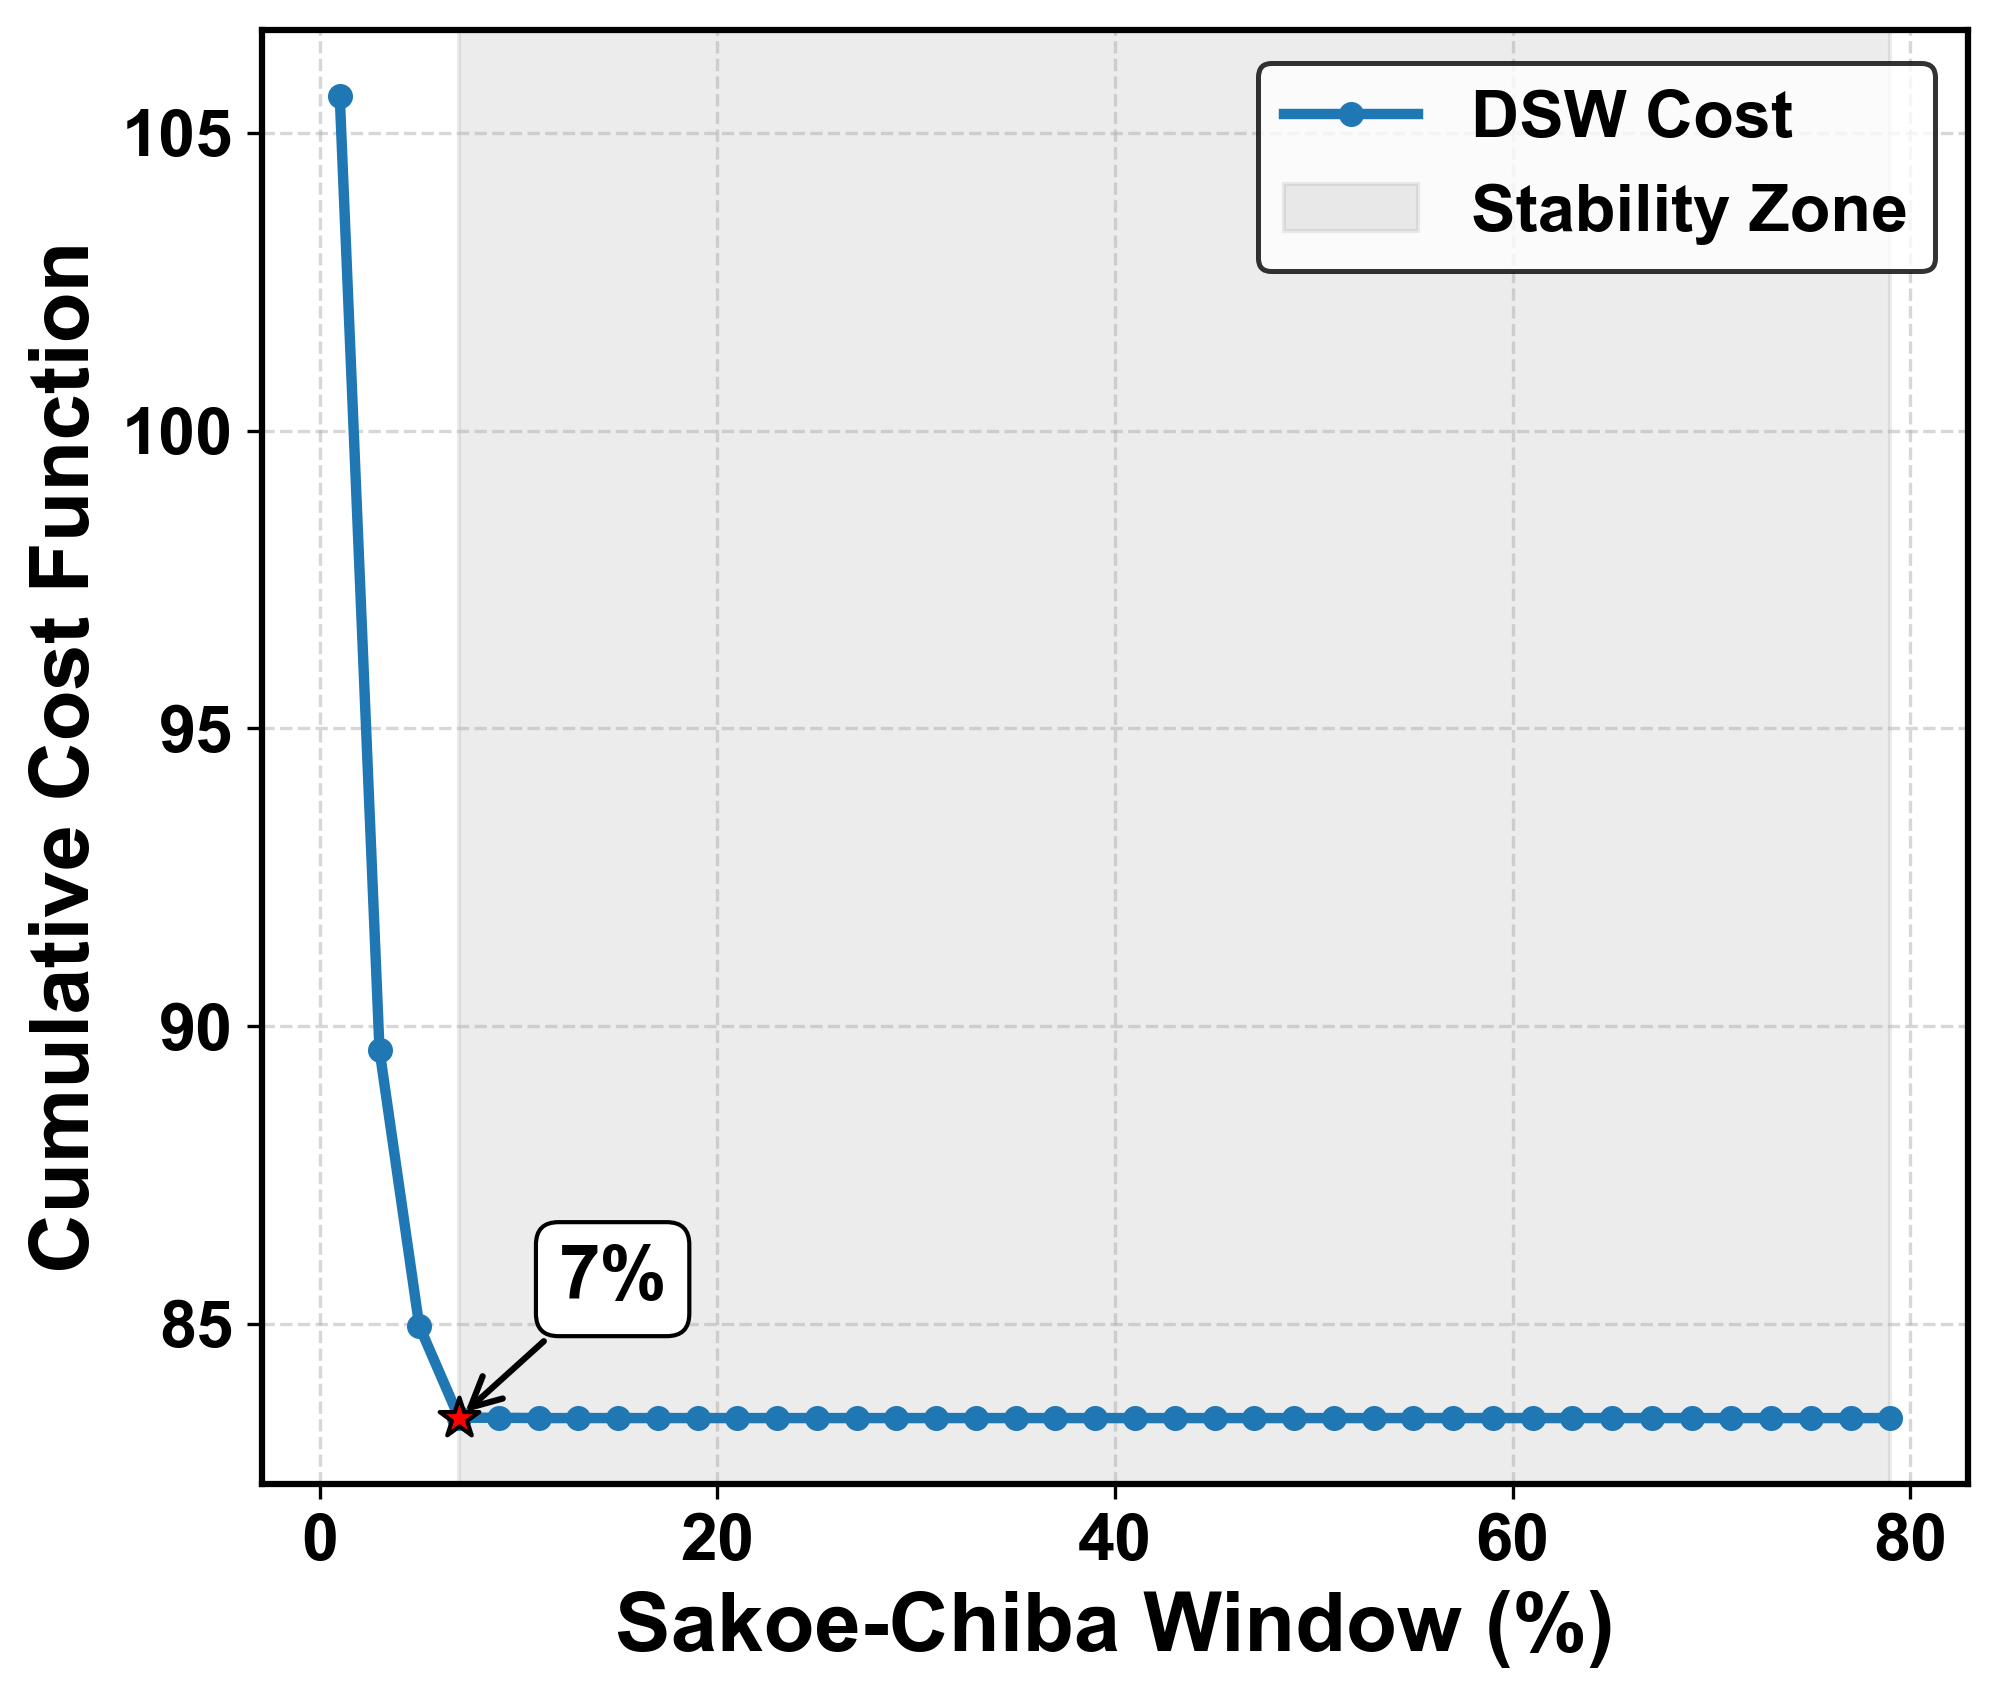

In [166]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming x_gr, y_gr already computed
# best_p, best_d already computed

fig, ax = plt.subplots(figsize=(7,6))

ax.plot(x_gr, y_gr, color='#1f77b4', lw=2.5, marker='o', ms=5, label='DSW Cost')

# Stability zone
ax.axvspan(best_p, max(x_gr), color='gray', alpha=0.15, label='Stability Zone')

# Optimal point
ax.scatter(best_p, best_d, color='red', edgecolor='black', s=100, marker='*', zorder=10)

# Annotation
ax.annotate(f'{best_p}%',
            xy=(best_p, best_d),
            xytext=(best_p + 5, best_d + 2),
            arrowprops=dict(arrowstyle='->', lw=1.5),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))





for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

# Labels
ax.set_xlabel("Sakoe-Chiba Window (%)")
ax.set_ylabel("Cumulative Cost Function")

# Legend (VISIBLE + CLEAN)
leg = ax.legend(loc='upper right', frameon=True)
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.2)

ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("NO159_J4ST2_GR_Lcurve.jpg", bbox_inches='tight', pad_inches=0.02)
plt.show()

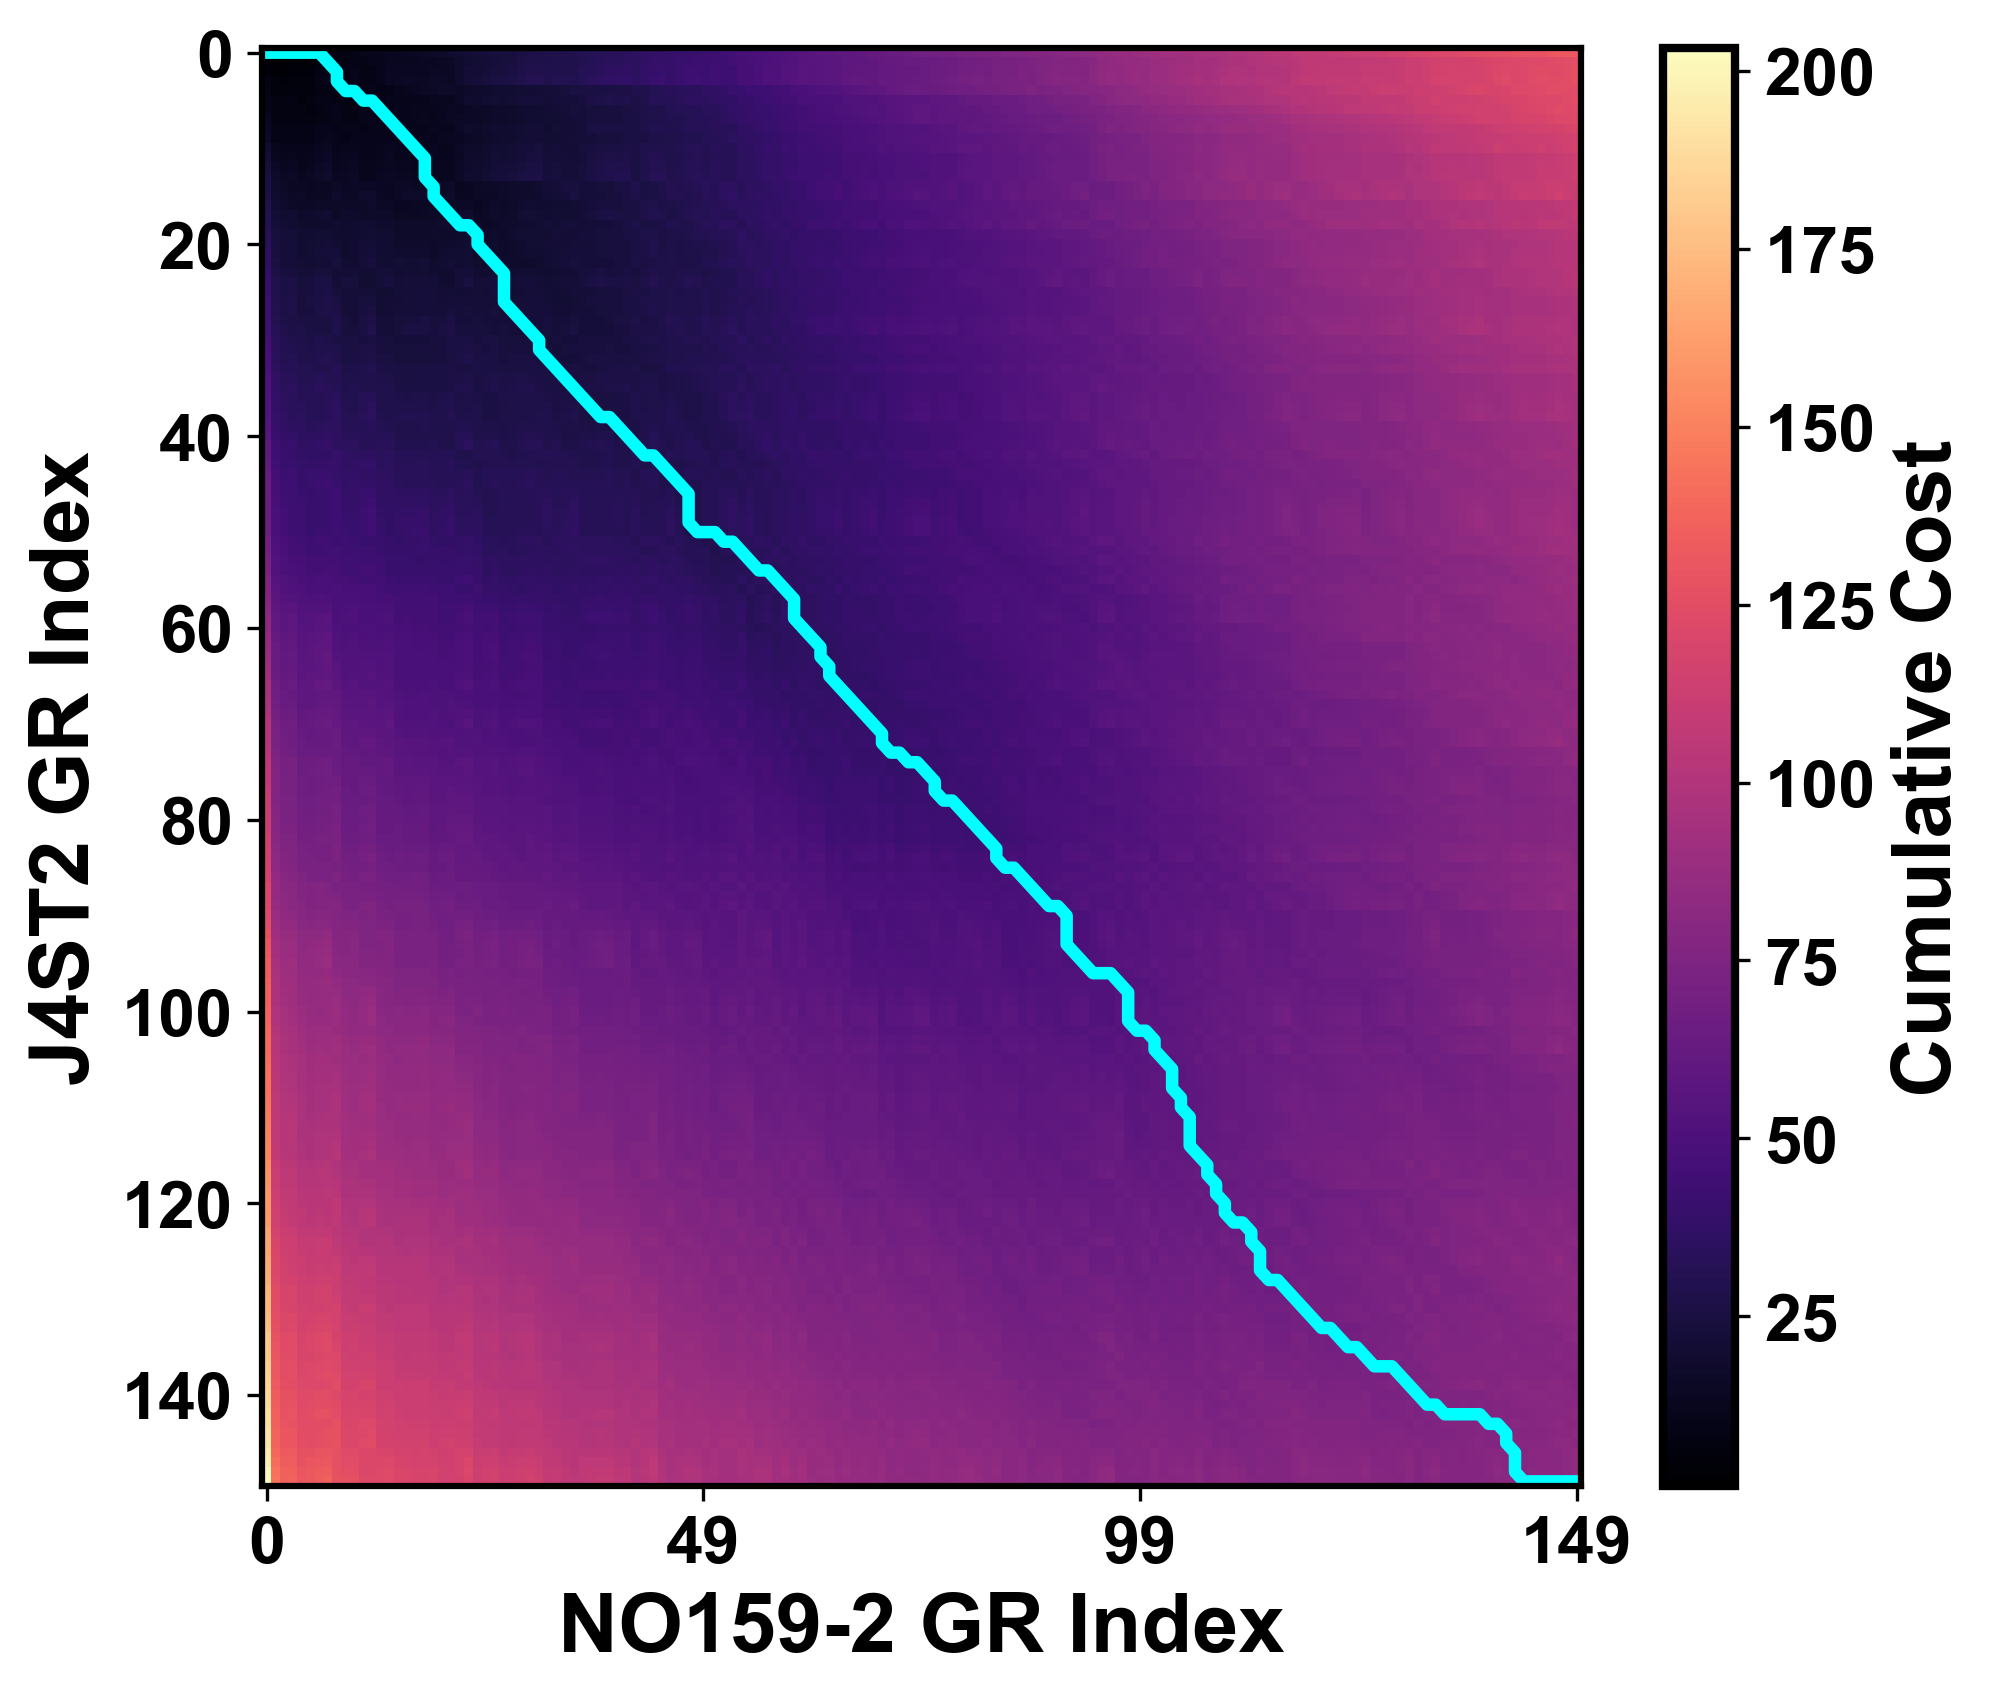

In [170]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# Set global RC params to match your first plot's style
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_dtw_full_matrix_styled(df1, df2, label1, label2):
    # 1. Standardize the Gamma Ray logs
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()
    
    n, m = len(s1), len(s2)

    # 2. Compute FULL Cumulative Cost Matrix (No Sakoe-Chiba window)
    dtw_matrix = np.zeros((n + 1, m + 1))
    dtw_matrix[1:, 0] = np.inf
    dtw_matrix[0, 1:] = np.inf
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],    # insertion
                                          dtw_matrix[i, j-1],    # deletion
                                          dtw_matrix[i-1, j-1])  # match

    # 3. Backtrack for Optimal Path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        move = np.argmin(steps)
        if move == 0: i, j = i-1, j-1
        elif move == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 4. Visualization (Matching your 1st plot's layout)
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Slice matrix to remove the padding row/column for visualization
    matrix_to_plot = dtw_matrix[1:, 1:]
    
    # Plot heatmap (transposed to match your orientation)
    img = ax.imshow(matrix_to_plot.T, origin='upper', cmap='magma', aspect='auto')
    
    # Plot Optimal Path
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3)

    # Labels (Matching 1st plot style)
    ax.set_xlabel(f"{label1} GR Index")
    ax.set_ylabel(f"{label2} GR Index")

    # X-Ticks logic from 1st code (4 ticks)
    xticks = np.linspace(0, n-1, 4) 
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])

    # Colorbar
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost")

    ax.grid(False)

    # Spine styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    plt.tight_layout()
    
    # Save logic
    save_dir = 'L_curve'
    if not os.path.exists(save_dir): os.makedirs(save_dir)
    plt.savefig(f"{save_dir}/{label1}_{label2}_Full_Warping.jpg", bbox_inches='tight')
    
    plt.show()

# CALL FOR YOUR NEW WELLS
plot_dtw_full_matrix_styled(df_no159, df_j4, "NO159-2", "J4ST2")

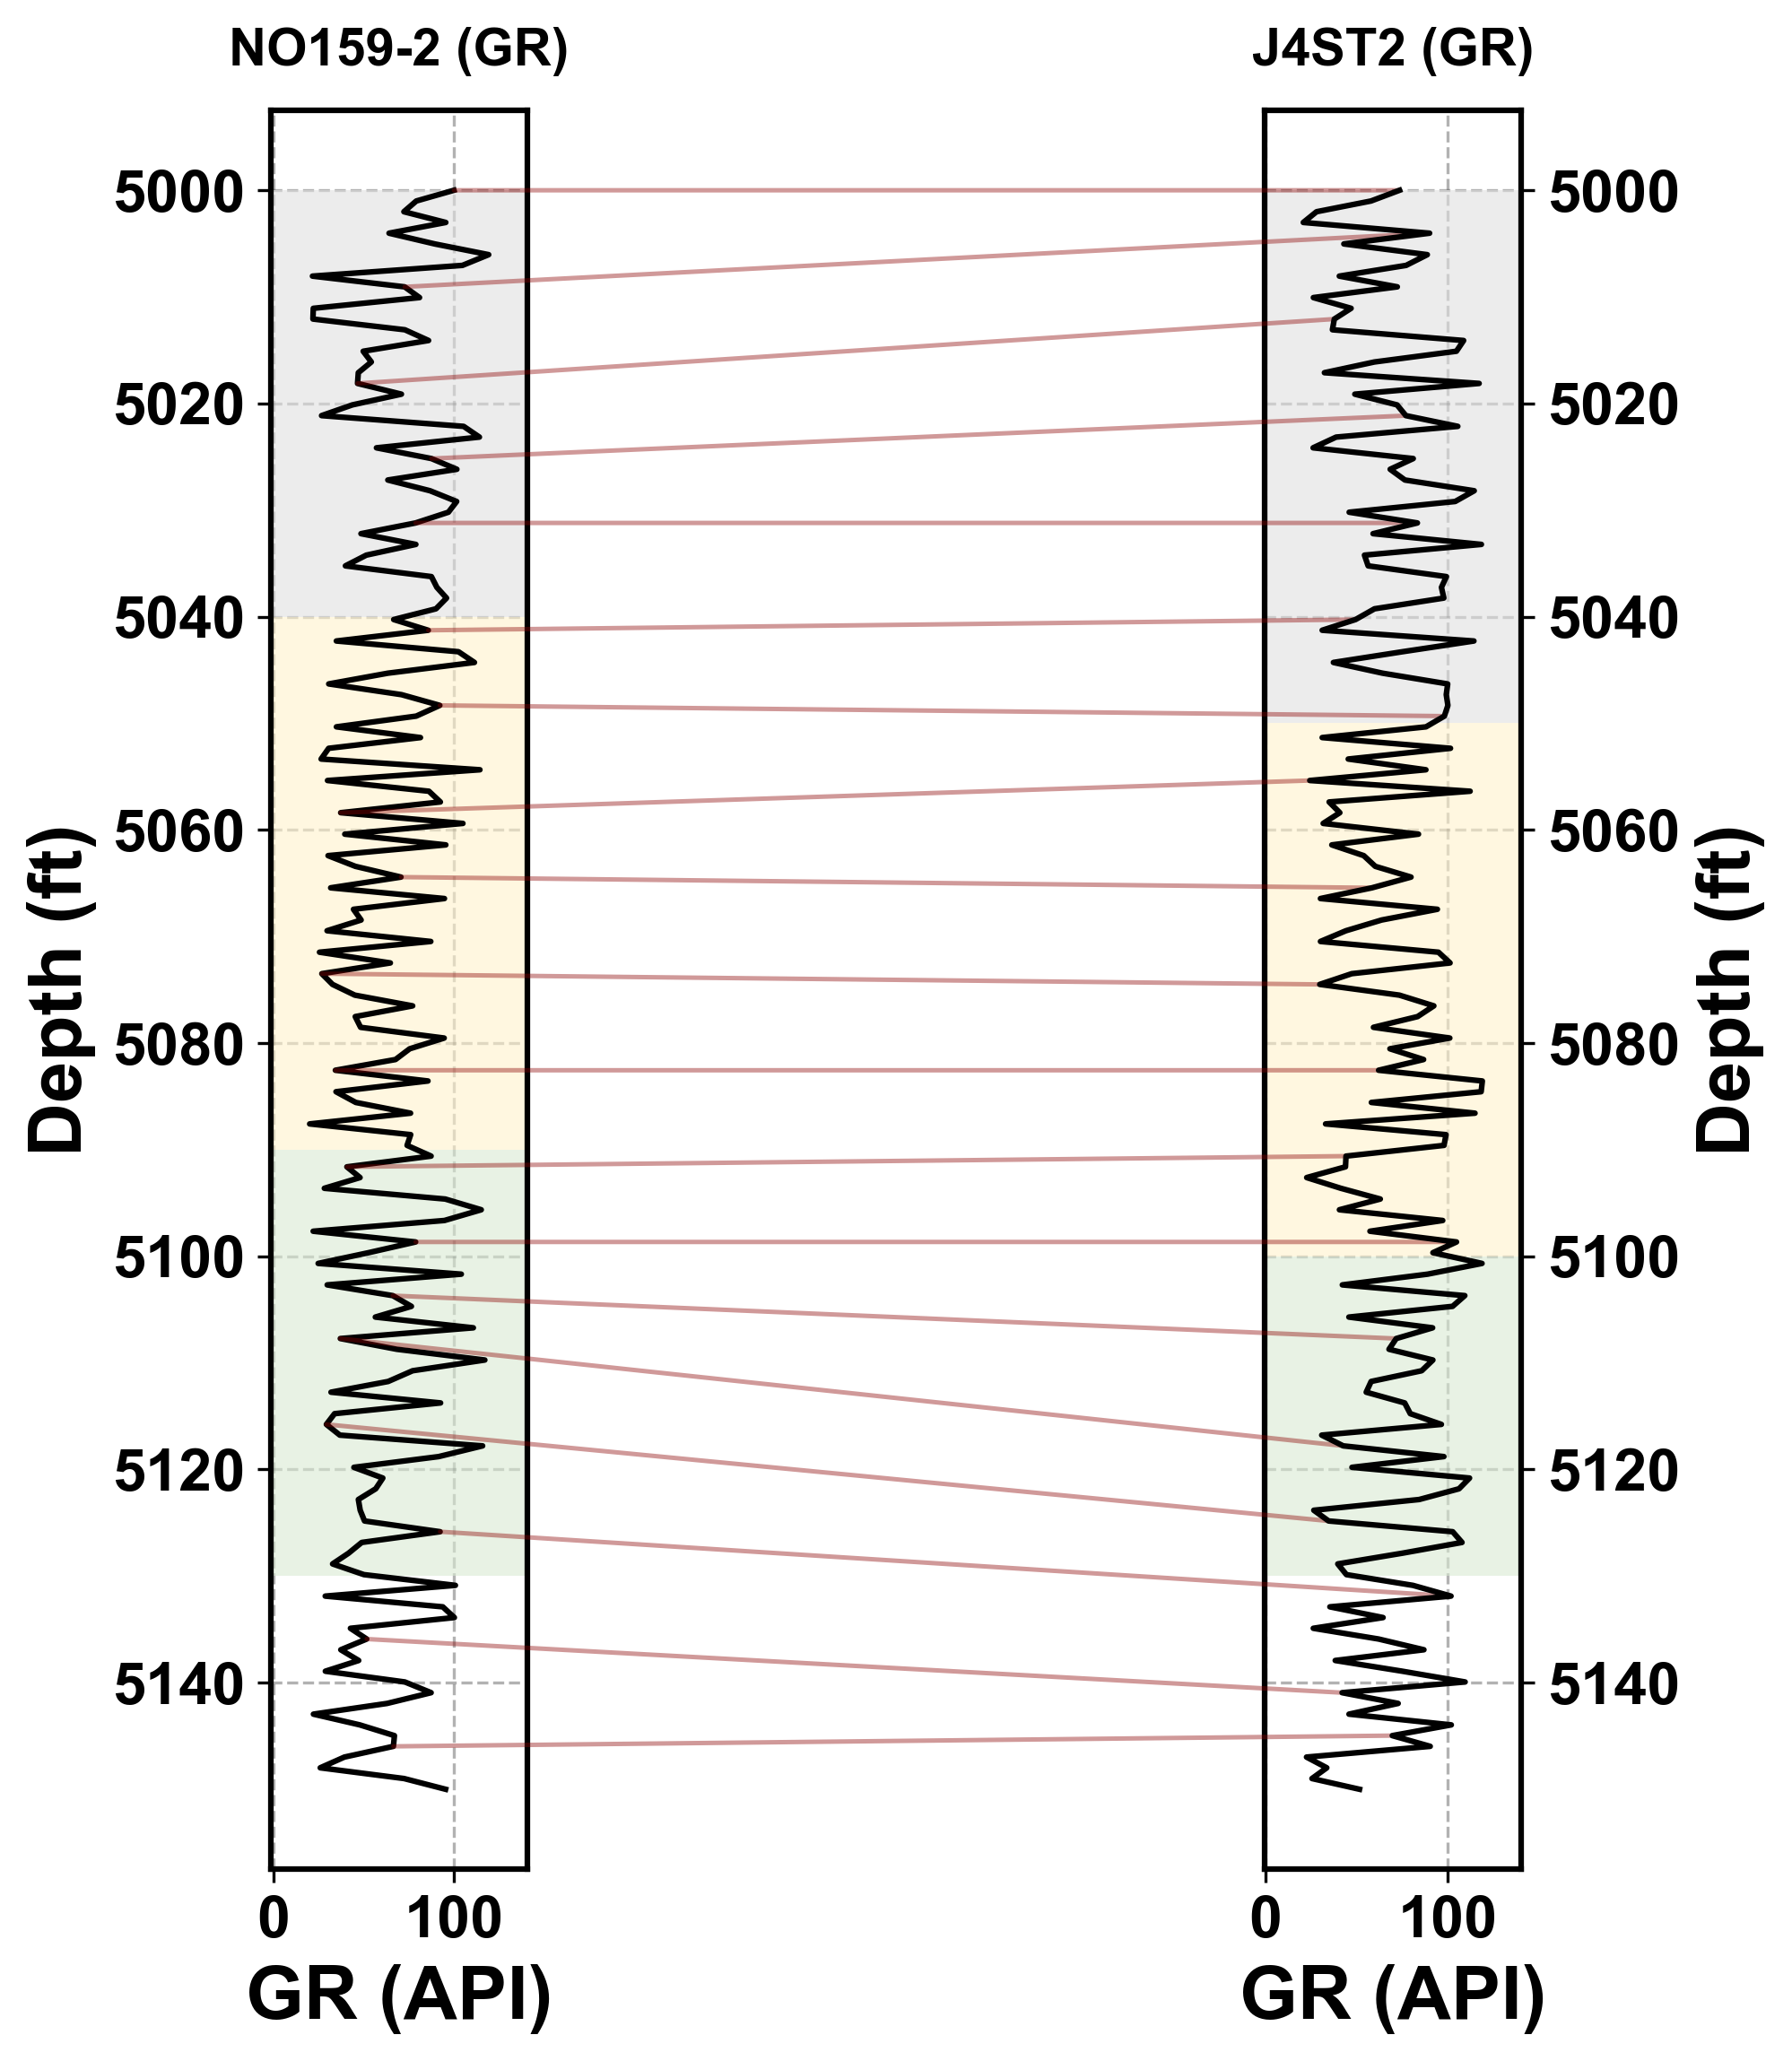

In [162]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler

# Set RC params to match the first plot's style (smaller, cleaner fonts)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})
def plot_gr_correlation_dummy(df1, df2, zones1, zones2, label1, label2, window_p):
    # 2. Standardize Log Data for DTW Processing
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1, 1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1, 1)).flatten()

    # Compute alignment path using your notebook's global DTW function
    path = dtw_with_path(s1, s2, window_p)

    fig, axes = plt.subplots(1, 2, figsize=(7, 8))

    for i, (df, zones, name) in enumerate([(df1, zones1, label1), (df2, zones2, label2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]

        # Plot Gamma Ray Curve
        ax.plot(gr, depth, color='black', lw=1.5, zorder=5)

        ax.invert_yaxis()
        ax.set_title(f"{name} (GR)", fontweight='bold', pad=12, fontsize=14)
        ax.set_xlabel("GR (API)", fontweight='bold')
        ax.set_ylabel("Depth (ft)", fontweight='bold')

        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()

        # Fill Geologic Formations (Using facecolor to clear warnings)
        for _, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.6, zorder=2)

        # Apply structural frame padding
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Border Spines Styling
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')
            
        ax.grid(True, alpha=0.3, linestyle='--', color='black', zorder=1)

    # 3. DRAW VISIBLE CORRELATION LINES
    # Step lowered from 120 to 10 to guarantee they populate nicely across shorter data rows
    line_density_step = 10 
    for k in range(0, len(path), line_density_step):
        i1, i2 = path[k]

        y1, x1 = df1.iloc[i1, 0], df1.iloc[i1, 1]
        y2, x2 = df2.iloc[i2, 0], df2.iloc[i2, 1]

        con = ConnectionPatch(
            xyA=(x1, y1), xyB=(x2, y2),
            coordsA="data", coordsB="data",
            axesA=axes[0], axesB=axes[1],
            color="darkred", lw=1.2, alpha=0.4, zorder=4
        )
        axes[1].add_artist(con)

    plt.tight_layout()
    plt.savefig(f"{label1}_{label2}_GR_Correlation_Fixed.jpg", bbox_inches='tight', dpi=300)
    plt.show()


# --- EXECUTE ---
# Run with your true dataframe variables, dummy-scaled zones, and an open window constraint (0.15)
plot_gr_correlation_dummy(df_no159, df_j4, zones_no159_2_dummy, zones_j4st2_dummy,
                          "NO159-2", "J4ST2", 0.07)

## NPHI

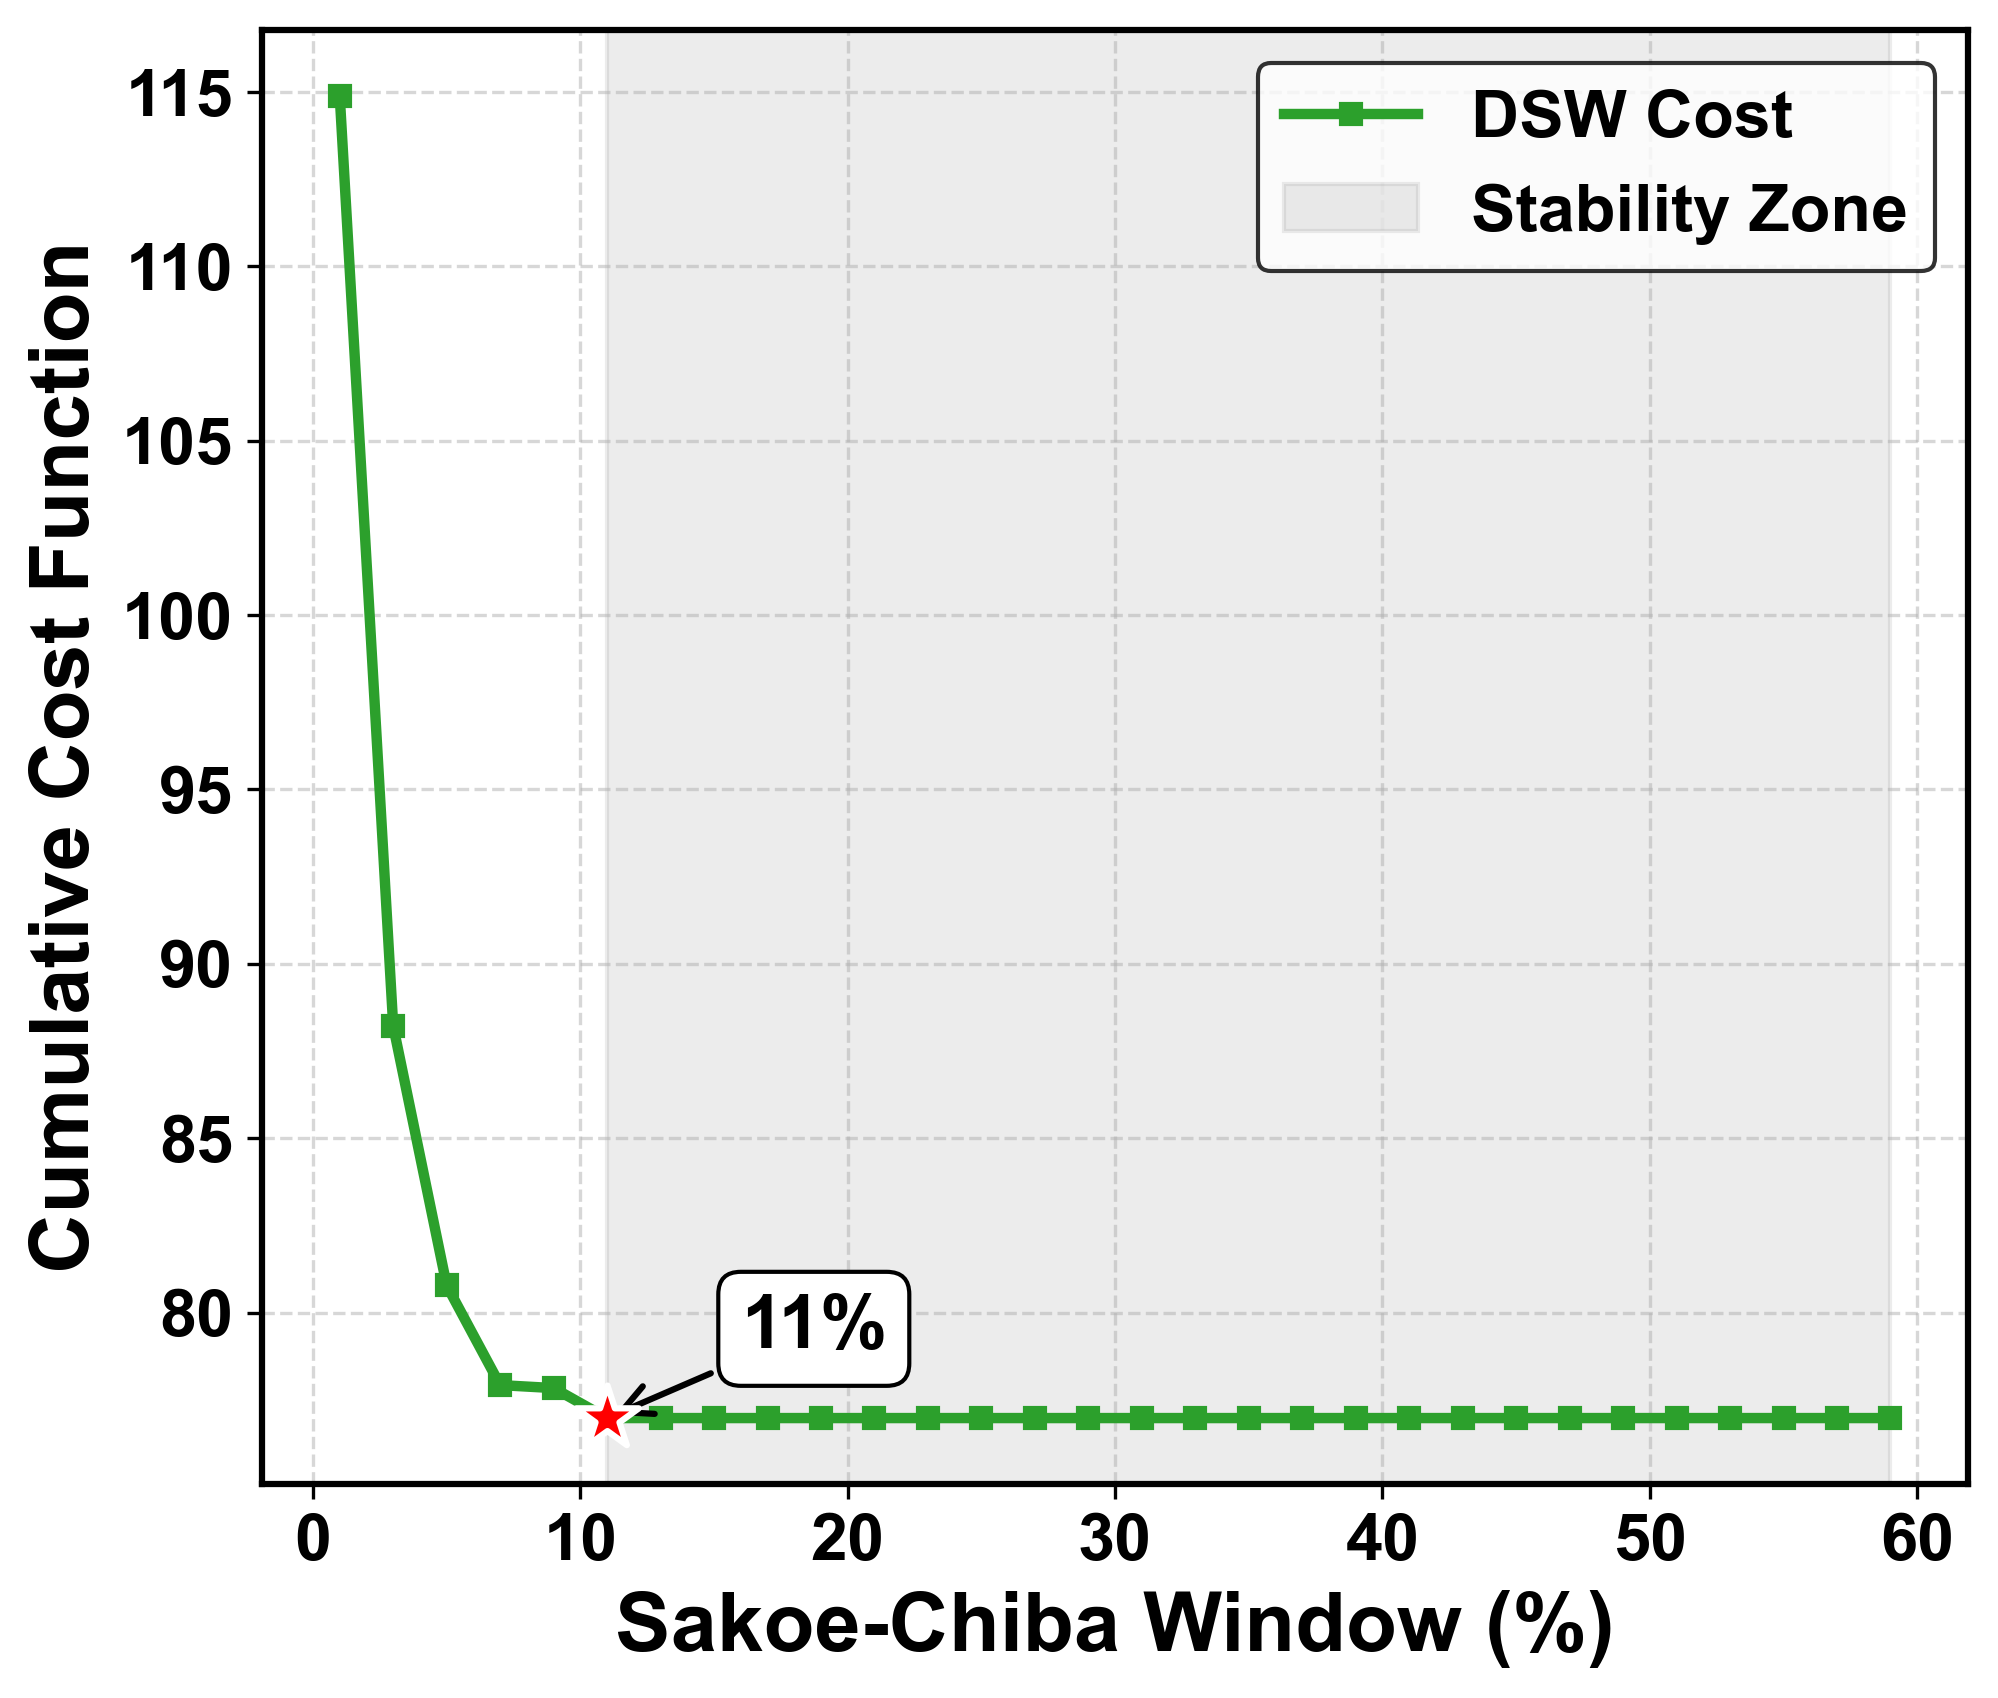

In [168]:
import numpy as np
import matplotlib.pyplot as plt

# x_nphi, y_nphi already computed
# best_p_nphi, best_d_nphi already computed

fig, ax = plt.subplots(figsize=(7,6))

ax.plot(x_nphi, y_nphi, color='#2ca02c', lw=2.5, marker='s', ms=5, label='DSW Cost')

ax.axvspan(best_p_nphi, max(x_nphi), color='gray', alpha=0.15, label='Stability Zone')

ax.scatter(best_p_nphi, best_d_nphi,
           color='red',
           edgecolor='white',
           linewidth=1.5,
           s=250,
           marker='*',
           zorder=20)
ax.annotate(f'{best_p_nphi}%',
            xy=(best_p_nphi, best_d_nphi),
            xytext=(best_p_nphi+5, best_d_nphi+2),
            arrowprops=dict(arrowstyle='->', lw=1.5),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

ax.set_xlabel("Sakoe-Chiba Window (%)")
ax.set_ylabel("Cumulative Cost Function")

leg = ax.legend(loc='upper right', frameon=True)
leg.get_frame().set_edgecolor('black')

ax.grid(True, linestyle='--', alpha=0.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')
plt.tight_layout()
plt.savefig("no_j4st2_NPHI_Lcurve.jpg", bbox_inches='tight')
plt.show()

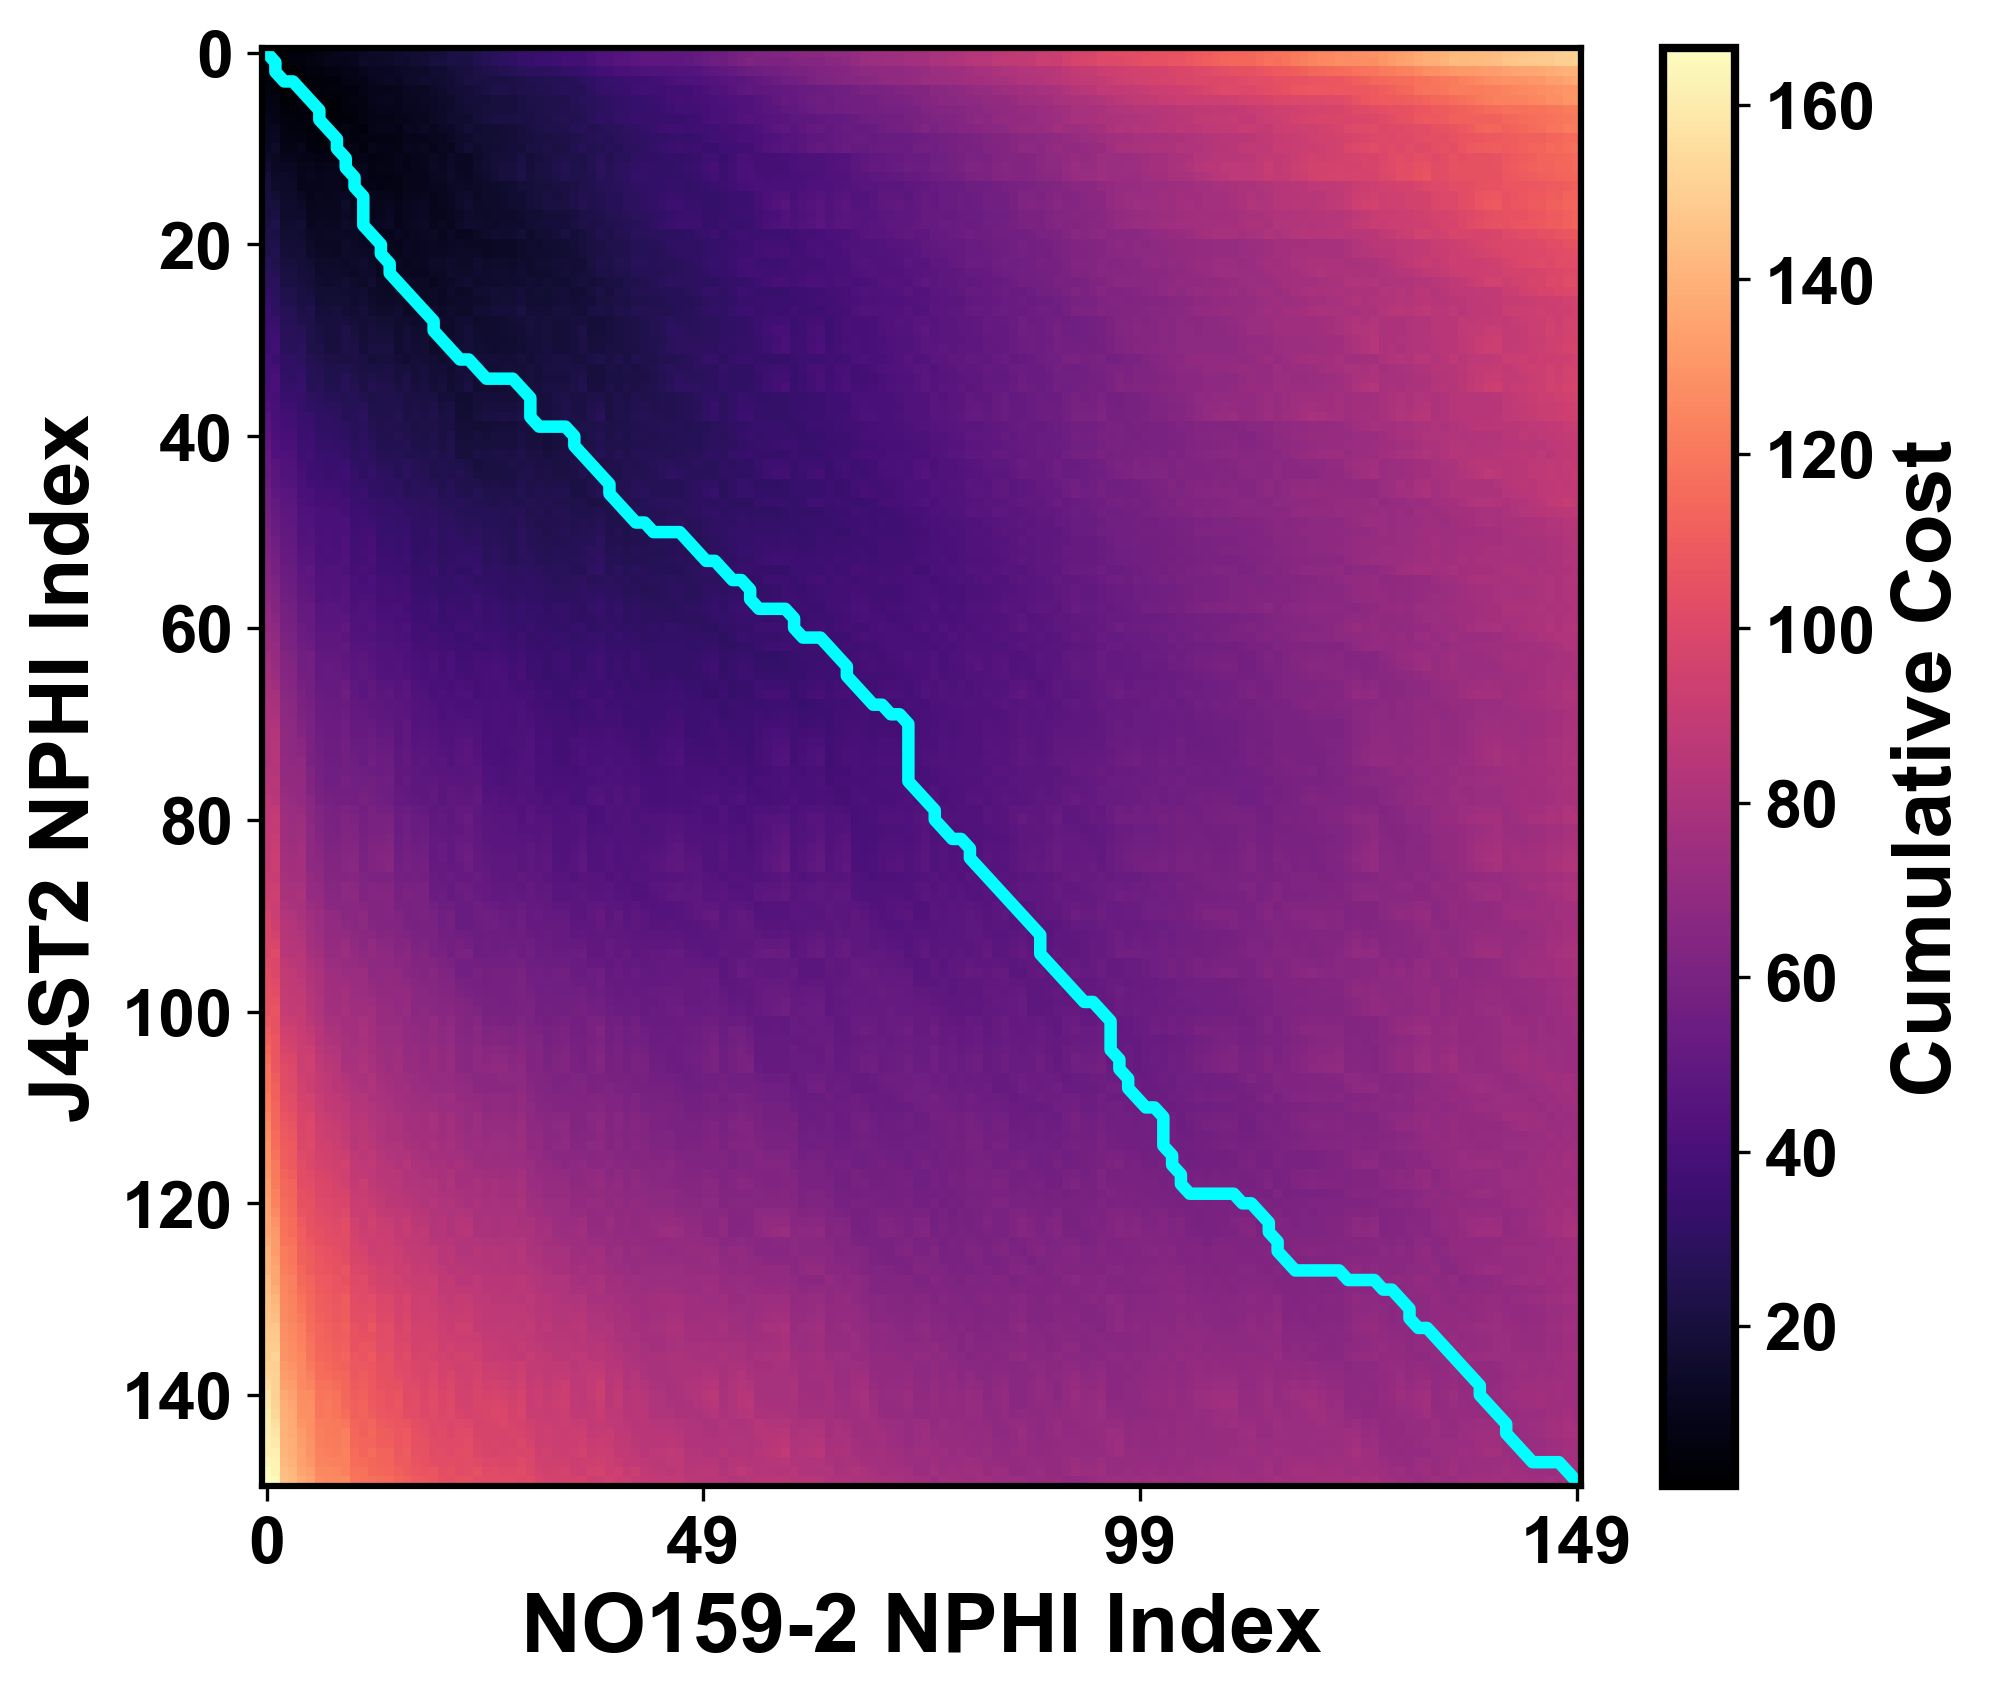

In [153]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# Ensure global styling matches your preferred aesthetic
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_nphi_warping_clean(df1, df2, label1, label2):
    # 1. Standardize the NPHI logs (Column Index 2)
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 2].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 2].values.reshape(-1,1)).flatten()

    n, m = len(s1), len(s2)

    # 2. Compute FULL Cumulative Cost Matrix
    dtw_matrix = np.zeros((n + 1, m + 1))
    dtw_matrix[1:, 0] = np.inf
    dtw_matrix[0, 1:] = np.inf
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])

    # 3. Backtracking
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        move = np.argmin(steps)
        if move == 0: i, j = i-1, j-1
        elif move == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 4. Visualization (7,6 for the clean look)
    fig, ax = plt.subplots(figsize=(7, 6))
    matrix_to_plot = dtw_matrix[1:, 1:]
    
    img = ax.imshow(matrix_to_plot.T, origin='upper', cmap='magma', aspect='auto')
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3)

    # Labels using the passed arguments
    ax.set_xlabel(f"{label1} NPHI Index")
    ax.set_ylabel(f"{label2} NPHI Index")

    # 4 Ticks on X-axis as per your requirement
    xticks = np.linspace(0, n-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])

    # Colorbar
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost")

    # Final Spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    plt.tight_layout()
    
    # Save logic
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    plt.savefig(f"L_curve/{label1}_{label2}_NPHI_Warping.jpg", bbox_inches='tight')
    plt.show()

# --- CALL FOR NO159-2 AND J4ST2 ---
plot_nphi_warping_clean(df_no159, df_j4, "NO159-2", "J4ST2")

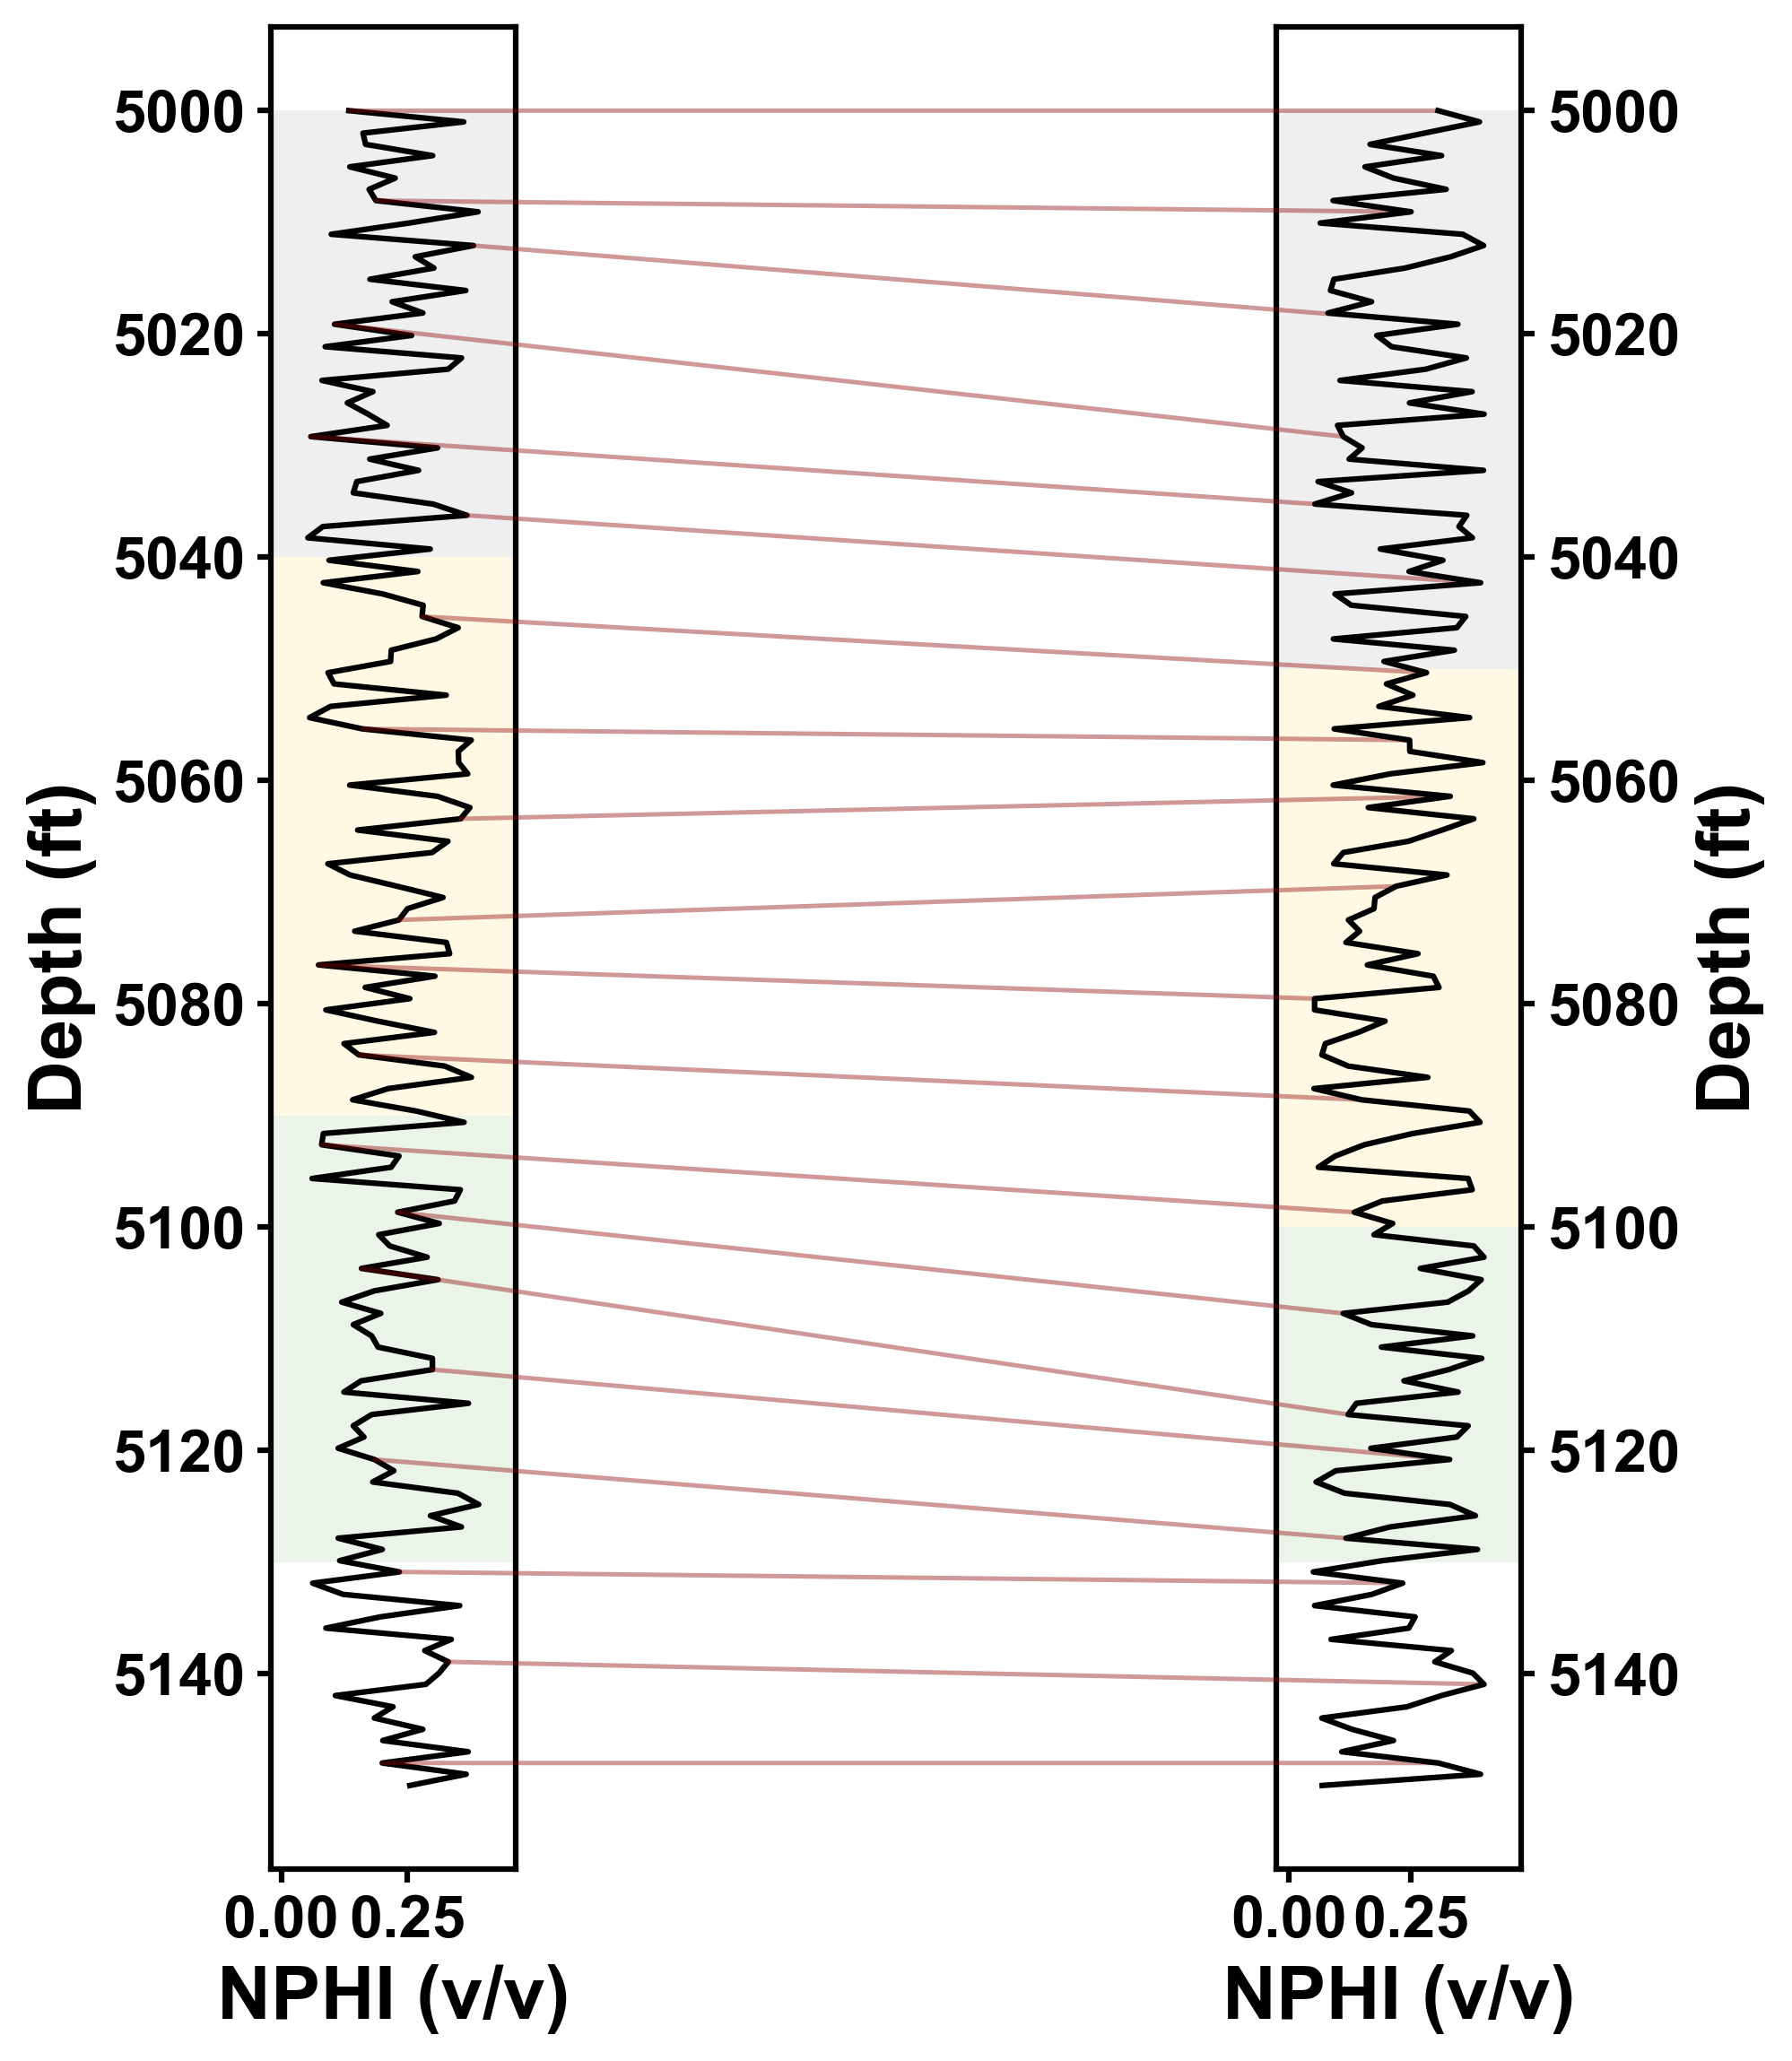

In [164]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler

# Maintaining the clean publication-style RC params
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_nphi_correlation_styled(df1, df2, zones1, zones2, label1, label2, window_p):
    # 1. Standardize NPHI logs (Column Index 2)
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 2].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 2].values.reshape(-1,1)).flatten()
    
    # Calculate path using your existing dtw_with_path logic
    path = dtw_with_path(s1, s2, window_p) 

    # 2. Setup Figure (7,8 aspect ratio)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8))

    for i, (df, zones) in enumerate([(df1, zones1), (df2, zones2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        nphi = df.iloc[:, 2] # NPHI column
        
        # Plot Log
        ax.plot(nphi, depth, color='black', lw=1.5, zorder=5)
        ax.invert_yaxis()
        
        ax.set_xlabel("NPHI (v/v)")
        ax.set_ylabel("Depth (ft)")

        # Handle secondary axis for the right well
        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()

        # Tick Styling
        ax.tick_params(axis='both', labelsize=16, width=1.5)

        # 3. Stratigraphic Zones (Fixed warning parameter by using facecolor)
        for _, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # Spacing fix (The "NPHI/GR pad")
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Spine Styling
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')

        ax.grid(False)

    # 4. Correlation Lines
    # --- FIX 1: Reduced step size from 120 to 10 for the short dummy files ---
    line_density_step = 10 

    for idx in range(0, len(path), line_density_step): 
        idx1, idx2 = path[idx]
        y1, x1 = df1.iloc[idx1, 0], df1.iloc[idx1, 2]
        y2, x2 = df2.iloc[idx2, 0], df2.iloc[idx2, 2]

        con = ConnectionPatch(xyA=(x1, y1), xyB=(x2, y2), 
                              coordsA="data", coordsB="data",
                              axesA=axes[0], axesB=axes[1], 
                              color="darkred", alpha=0.4, lw=1.2, zorder=4)
        axes[1].add_artist(con)    

    plt.tight_layout()

    # 5. Save logic
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_file = f'L_curve/{label1}_{label2}_NPHI_Correlation.jpg'
    #plt.savefig(save_file, dpi=400, bbox_inches='tight')
    
    plt.show()

plot_nphi_correlation_styled(df_no159, df_j4, zones_no159_2_dummy, zones_j4st2_dummy, "NO159-2", "J4ST2", 0.11)

##### 